In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
# Установка pyreadstat, если он еще не установлен
# Библиотека Python для чтения статистических файлов
try:
    import pyreadstat
    print("Библиотека pyreadstat уже установлена.")
except ImportError:
    print("Устанавливаем pyreadstat...")
    !pip install pyreadstat

Устанавливаем pyreadstat...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 617.7/617.7 kB 8.0 MB/s eta 0:00:00


# Задание №0: Загрузка и предварительная обработка данных

1. Загрузите данные RLMS (например, в формате .sav) с официального источника [RLMS](https://hse.ru/rlms).

2. Выполните очистку и гармонизацию данных:
- Приведение имён столбцов к нижнему регистру и удаление лишних пробелов.
- Обработка пропусков и рекодирование категориальных переменных.
- Объединение домохозяйственных и индивидуальных анкет (используйте переменные вида `bbidindX`).

In [ ]:
# подгружаем файлы с данными, для этого заходим в гугл диск и скачиваем оттуда два файла
#Логин: Komprak7@gmail.com
#Пароль: comprak04
from google.colab import files
uploaded = files.upload()

Saving r32h_os_71.sav to r32h_os_71 (1).sav
Saving r32i_os_73.sav to r32i_os_73.sav


In [ ]:
# кладём путь наших файлов в переменные
f_p_individuals = 'r32i_os_73.sav'
f_p_homes = 'r32h_os_71.sav'
# проверяем, что данные считаны и загружены, иначе ошибка
try:
    df_i = pd.read_spss(f_p_individuals)  # таблица с данными об индивидах
    df_h = pd.read_spss(f_p_homes)        # таблица с данными о домохозяйствах
    print("Данные загружены успешно!")
    # посмотрим первые строки данных
    print(df_i.head())
    print(df_h.head())
except Exception as e:
    print(f"Ошибка загрузки: {e}")

Данные загружены успешно!
   idind  bbredid_i     bbid_i   bbid_h     aaid_i   aaid_h      zid_i  \
0    7.0    66301.0  1000301.0  10003.0  1000301.0  10003.0  1000301.0   
1   92.0    68001.0  1008401.0  10084.0  1008401.0  10084.0  1008401.0   
2   93.0    68002.0  1008402.0  10084.0  1008402.0  10084.0  1008402.0   
3   95.0    68004.0  1008404.0  10084.0  1008404.0  10084.0  1008404.0   
4  102.0    68101.0  1008601.0  10086.0  1008601.0  10086.0  1008601.0   

     zid_h      yid_i    yid_h  ...  bbl53  bbl54  bbm96  bbm97  bbm98  bbm99  \
0  10003.0  1000301.0  10003.0  ...    NaN    NaN    NaN    NaN    NaN    NaN   
1  10084.0  1008401.0  10084.0  ...    NaN    NaN    NaN    NaN    NaN    NaN   
2  10084.0  1008402.0  10084.0  ...    NaN    NaN    NaN    NaN    NaN    NaN   
3  10084.0  1008404.0  10084.0  ...    NaN    NaN    NaN    NaN    NaN    NaN   
4  10086.0  1008601.0  10086.0  ...    NaN    NaN    NaN    NaN    NaN    NaN   

   bbm100  bbm101  bbm109  bbm111  
0     

In [ ]:
# Приведение имён столбцов к нижнему регистру и удаление лишних пробелов
df_i = df_i.rename(columns=lambda x: x.strip().lower())
df_h = df_h.rename(columns=lambda x: x.strip().lower())

# объединяем данные по столбцу bbid_h
rlms_df = df_i.merge(df_h, on='bbid_h', how='left', suffixes=('_ind', '_hh'))
# left join: оставляем все строки из df_i (индивидуальные данные), а из df_h берём только те, которые совпадают по bbid_h
# suffixes=(): добавляем суффиксы к столбцам с одинаковыми именами, чтобы избежать конфликтов

# Задание №2: Дети

В этом задании вам нужно изучить факторы, связанные с количеством детей у россиян. Для этого вы будете использовать данные опроса RLMS за последний доступный год (2023).

Для того, чтобы понять родственные связи членов домохозяйства, мы будем использовать переменные из опросника по домохозяйствам вида «bbb**X**.9.**Y**»,  где X и Y – номера членов домохозяйства. Из этих показателей несложно восстановить полную структуру семьи.
Для того, чтобы подтянуть к характеристикам домохозяйства данные по отдельным его членам, вы можете использовать переменные вида «bbidind**X**», (где X – номер члена домохозяйства): в них находятся идентификационные номера членов семьи, по которым их можно найти в опроснике по индивидам.


### 2.1 Среднее число детей

Начнём с простого: рассчитаем среднее число детей (в семье) в зависимости от того, в городе живёт семья или в сельской местности и в зависимости от численности населения населённого пункта. Визуализируйте эти результаты на графике.

In [ ]:
# Функция для подсчета количества детей
def compute_children_count_fast(
        df: pd.DataFrame,
        child_labels: list[str] = ('Сын/дочь',
                                   'Внук/внучка',
                                   'Неродной сын/неродная дочь')
    ) -> pd.DataFrame:
    """
    Считает количество детей в домохозяйстве.
    df            : DataFrame, где колонки bbbX.9.Y уже превращены в строковые метки
    child_labels  : какие строки считать «ребёнком» (можно расширить по желанию)
    """
    # 1. ищем все переменные вида bbbX.9.Y  (точки или подчёрк.)
    pattern = r'bbb\d+(?:[._]9[._]\d+)'     # регулярное выражение для поиска колонок
    child_cols = [c for c in df.columns if re.fullmatch(pattern, c)]
    if not child_cols:
        raise ValueError('Не найдено колонок bbbX.9.Y. Проверьте имена.')

    # 2. бинарная таблица, где 1 - член семьи по колонке — ребёнок (т.е. в child_labels)
    child_flags = df[child_cols].isin(child_labels).astype(int)

    # 3. группируем колонки по X (если колонки называются bbb1.9.1, bbb1.9.2, bbb2.9.1,
    # то они разбиваются в словарь groups), считаем «есть ли ребёнок» для каждого X
    groups: dict[str, list[str]] = {}
    for col in child_cols:
        groups.setdefault(re.match(r'bbb(\d+)', col).group(1), []).append(col)
    # 4. для каждой группы считаем, есть ли в ней дети, записываем в count
    count = pd.Series(0, index=df.index)
    for cols in groups.values():
        count += (child_flags[cols].sum(axis=1) > 0).astype(int)
    # 5. добавляем результат в новый столбец children_count в копию нашей таблицы
    out = df.copy()
    out['children_count'] = count
    print(f'[children_count] колонок = {len(child_cols)}, '
          f'домов с детьми = {(count>0).sum()}/{len(df)}')

    return out
# применяем функцию к датафрейму домохозяйств
df_h = compute_children_count_fast(df_h,
                                   child_labels=['Сын/дочь',
                                                 'Внук/внучка',
                                                 'Неродной сын/неродная дочь'])

# удаляем строки, в которых тип населённого пункта или размер поселения отсутствуют
df_h = df_h.dropna(subset=['status', 'popul'])

# группируем по типу ("город"/"село") и считаем среднее число детей
type_group = (
    df_h.groupby('status', observed=True)['children_count']
    .mean().reset_index()
)

print(type_group)


[children_count] колонок = 144, домов с детьми = 2287/4788
            status  children_count
0            Город        0.805490
1  Областной центр        0.829724
2              ПГТ        0.948276
3             Село        0.988526


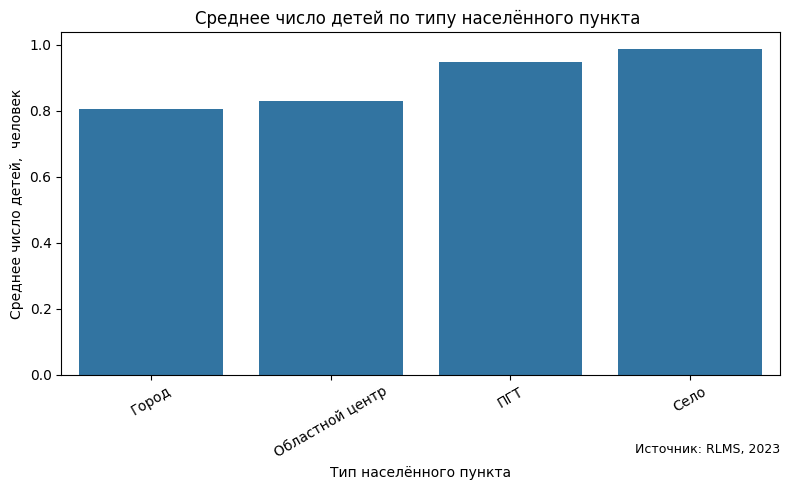

Максимальное значение popul: 12835600.0
Бины: [0, 10000, 100000, 12835601.0]


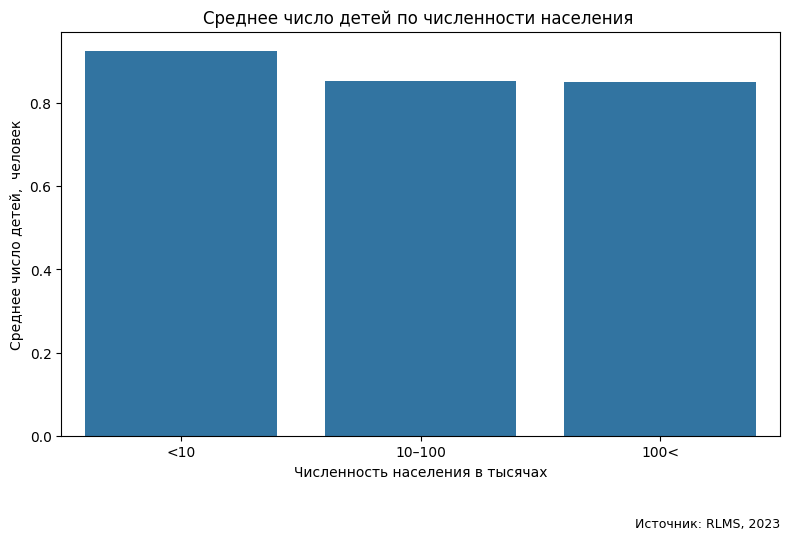

In [ ]:
# TODO: Постройте график
# аостроение графика по типу населённого пункта
plt.figure(figsize=(8, 5))
sns.barplot(data=type_group, x='status', y='children_count')
plt.title('Среднее число детей по типу населённого пункта ')
plt.ylabel('Среднее число детей,  человек')
plt.xlabel('Тип населённого пункта')
plt.xticks(rotation=30)
plt.tight_layout() # автоматически подгоняет график, чтоб ничего не перекрывалось
plt.text(1.0, -0.2, 'Источник: RLMS, 2023',
         ha='right', va='top', fontsize=9, transform=plt.gca().transAxes)
plt.show()

# группировка по численности населения с исправлением бинов (интервалов)
max_popul = df_h['popul'].max()  # получаем максимальное значение населения
print(f"Максимальное значение popul: {max_popul}")  # для проверки

# создаем бины, которые будут строго возрастающими
bins = [0, 10000, 100000]  # убираем 1000000, так как max_popul меньше
if max_popul > 100000:  # если max_popul больше 100000, добавляем его + 1 как последний бин
    bins.append(max_popul + 1)
else:
    bins.append(100001)  # иначе добавляем значение чуть больше 100000

print(f"Бины: {bins}")  # проверяем порядок бинов
labels = ['<10', '10–100', '100<']  # уменьшаем количество меток, чтобы соответствовать количеству интервалов (для наглядности)

# создаем столбец pop_group с помощью pd.cut (делит население на категории по bins, присваивает метку из labels каждому дому)
df_h['pop_group'] = pd.cut(df_h['popul'], bins=bins, labels=labels, include_lowest=True)

# группируем по интервалам численности и вычисляем среднее количество детей
pop_group = df_h.groupby('pop_group', observed=True)['children_count'].mean().reset_index()

# построение графика по численности населения
plt.figure(figsize=(8, 5))
sns.barplot(data=pop_group, x='pop_group', y='children_count')
plt.title('Среднее число детей по численности населения ')
plt.ylabel('Среднее число детей,  человек')
plt.xlabel('Численность населения в тысячах')
plt.tight_layout()
plt.text(1.0, -0.2, 'Источник: RLMS, 2023',
         ha='right', va='top', fontsize=9, transform=plt.gca().transAxes)
plt.show()

### 2.2 Суммарный доход семьи и связь с числом детей

Для каждой семьи (вне зависимости от наличия или отсутствия в ней детей) рассчитайте её суммарный доход. Сюда надо включить доход обоих родителей, бабушек-дедушек (если они проживают совместно с детьми и внуками), доход как трудовой от разных мест работы, так и пенсии и пособия. Обратите внимание, это несколько разных показателей, их можно найти, поискав по файлу опросника индивидов фразу «сколько денег».

Как связан доход семьи с числом детей? Визуализируйте эту связь как для всей выборки, так и для подвыборок в зависимости от типа населённого пункта, состава семьи (наличия/отсутствия бабушек-дедушек в том же домохозяйства) и других факторов, которые, по вашему мнению, могут влиять на эту связь.

In [ ]:
4

[family_income] учтено 4 колонок; семей с ненулевым доходом = 4647
    bbid_h  family_income
0  10003.0            5.0
1  10014.0            3.0
2  10016.0        51075.0
3  10018.0        25002.0
4  10023.0            2.0


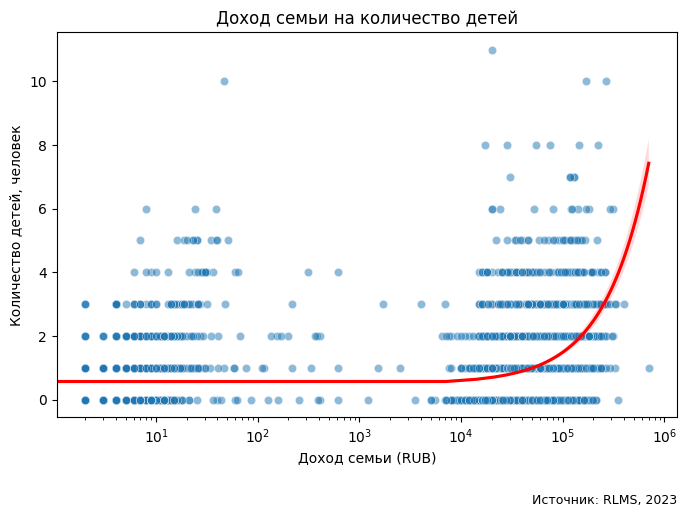

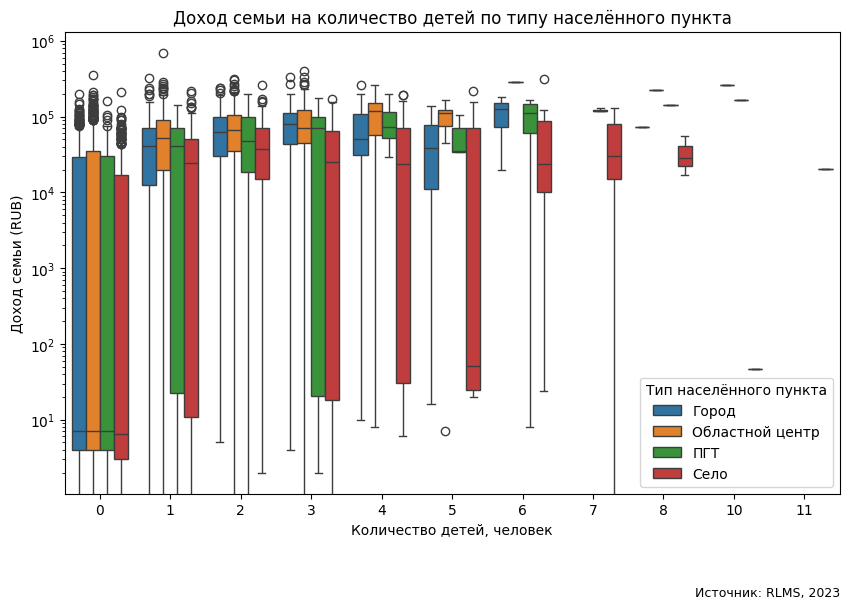

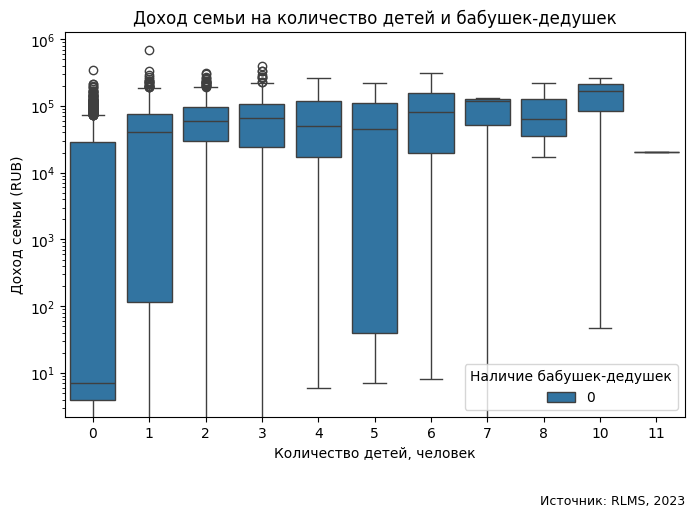

In [ ]:
# TODO: Постройте график
# визуализируем общую связь между доходом семьи и количеством детей
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_h_with_income, x='family_income', y='children_count', alpha=0.5)
sns.regplot(data=df_h_with_income, x='family_income', y='children_count', scatter=False, color='red')
plt.title('Доход семьи на количество детей')
plt.xlabel('Доход семьи (RUB)')
plt.ylabel('Количество детей, человек')
plt.xscale('log')  # используем логарифмическую шкалу из-за возможной скошенности данных
plt.text(1.0, -0.2, 'Источник: RLMS, 2023',
         ha='right', va='top', fontsize=9, transform=plt.gca().transAxes)
plt.show()

# визуализируем связь по типу населённого пункта
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_h_with_income, x='children_count', y='family_income', hue='status')
# коробка с усами для каждого количества детей и каждого типа населённого пункта
plt.title('Доход семьи на количество детей по типу населённого пункта')
plt.xlabel('Количество детей, человек')
plt.ylabel('Доход семьи (RUB)')
plt.yscale('log')
plt.legend(title='Тип населённого пункта')
plt.text(1.0, -0.2, 'Источник: RLMS, 2023',
         ha='right', va='top', fontsize=9, transform=plt.gca().transAxes)
plt.show()

# функция показывает есть бабушки-дедушки
def identify_grandparents(df):
    # находим столбцы, соответствующие шаблону bbbX.9.Y
    relation_cols = [col for col in df.columns if re.fullmatch(r'bbb\d+\.9\.\d+', col)]
    # помечаем домохозяйства с бабушками-дедушками (код отношения 8 из кодификатора родственных связей )
    df['has_grandparents'] = df[relation_cols].apply(
        lambda row: 1 if any(row == 8) else 0, axis=1
    )
    return df
# Применяем функцию и визуализируем по наличию бабушек-дедушек
df_h_with_income = identify_grandparents(df_h_with_income)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_h_with_income, x='children_count', y='family_income', hue='has_grandparents')
# коробка с усами по количеству детей, отдельно для домохозяйств с бабушками/дедушками и без
plt.title('Доход семьи на количество детей и бабушек-дедушек')
plt.xlabel('Количество детей, человек')
plt.ylabel('Доход семьи (RUB)')
plt.yscale('log')
plt.legend(title='Наличие бабушек-дедушек')
plt.text(1.0, -0.2, 'Источник: RLMS, 2023',
         ha='right', va='top', fontsize=9, transform=plt.gca().transAxes)
plt.show()

### 2.3 Формулировка и проверка гипотез II

1. Изучите доступные в RLMS данные и сформулируйте три разные гипотезы о том, что может влиять на количество детей (помимо типа населённого пункта и дохода). При формулировке гипотез обязательно приведите ссылки на релевантные, актуальные и авторитетные источники (научные исследования по схожей проблематике на зарубежном статистическом материале).

2. Проверьте ваши гипотезы на данных. Для этого сформулируйте необходимые разрезы данных, рассчитайте статистики, визуализируйте (в виде графиков или таблиц) ваши расчёты. Сделайте вывод о том, как результаты соотносятся со сформулированными гипотезами.

3. Кратко охарактеризуйте результаты вашего исследования в рамках одного абзаца текста.

Гипотеза 1: Уровень образования родителей

Гипотеза: Более высокий уровень образования родителей связан с меньшим количеством детей из-за отсрочки рождения детей и ориентации на карьеру.

1. «Результаты регрессионного анализа подтвердили негативное влияние высшего образования женщины на количество детей (−0.145***)».
«Женщина с высшим образованием начинает значительно позже реализовывать себя в роли жены и матери, поэтому у нее меньше времени на реализацию репродуктивных предпочтений».

Источник: Карабчук Т. С., Кечетова А. П. Количество детей и семейные ценности: существуют ли когортные различия в Европе? // Журнал исследований социальной политики. — 2017. — Т. 15, № 2. — С. 245–266.

2. «Наиболее обеспеченные и образованные родители не только фактически имеют, но и намерены иметь меньше детей»

Источник: Сивоплясова С. Ю., Сигарева Е. П., Архангельский В. Н. Уровень жизни и рождаемость: взаимосвязь двух неравенств на макро- и микроуровнях // Демографическое обозрение. — 2022. — Т. 9, № 4. — С. 37–58.

Этими источниками мы подтвержаем нашу гипотезу.
Переменная: bbj72.18a (уровень образования)

Строк для анализа: 4787


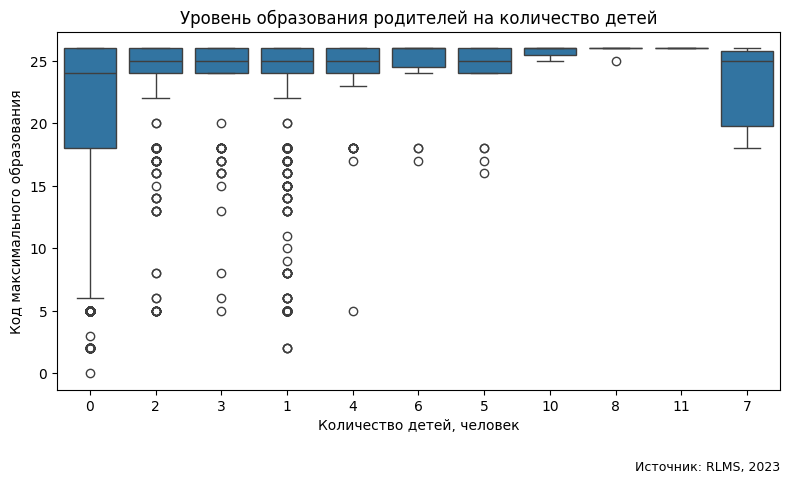

children_count
0     21.062400
1     23.166667
2     24.083095
3     24.312268
4     24.357143
5     24.512821
6     24.066667
7     23.000000
8     25.833333
10    25.666667
11    26.000000
Name: max_edu_code, dtype: float64


In [ ]:
if 'df_h_with_income' not in globals():
    df_h_with_income = df_h.copy() # проверяем есть ли эта переменная

# кодируем уровень образования (получаем числовые коды)
codes = rlms_df['bb_educ'].cat.codes
rlms_df['_edu_code'] = np.where(codes == -1, np.nan, codes)

# берем максимальный уровень образование по каждому дому
education_level = (rlms_df
                   .groupby('bbid_h', observed=True)['_edu_code']
                   .max(min_count=1)
                   .reset_index()
                   .rename(columns={'_edu_code': 'max_edu_code'}))

# удаляем старые версии макс обр.,
# обьединяем с таблицей уровней образования по bbid_h, удаляем пустоты
df_h1 = (df_h_with_income
         .drop(columns=[c for c in df_h_with_income.columns
                        if c.startswith('max_edu_code')], errors='ignore')
         .merge(education_level, on='bbid_h', how='left')
         .dropna(subset=['max_edu_code']))

# проверяем
print("Строк для анализа:", len(df_h1))
if df_h1.empty:
    raise ValueError("В этой волне нет заполненного bb_educ – график строить не из чего.")

# создаём версию по категориям children_count,
# чтобы отображать количество детей как строку
df_h1['children_count_cat'] = df_h1['children_count'].astype(int).astype(str)

# строим
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_h1, x='children_count_cat', y='max_edu_code')
plt.title('Уровень образования родителей на количество детей')
plt.xlabel('Количество детей, человек'); plt.ylabel('Код максимального образования')
plt.text(1.0, -0.2, 'Источник: RLMS, 2023',
         ha='right', va='top', fontsize=9, transform=plt.gca().transAxes)
plt.tight_layout(); plt.show()

print(df_h1.groupby('children_count')['max_edu_code'].mean())

Гипотеза 2: Статус занятости матерей

Гипотеза: Занятые матери имеют меньше детей из-за ограничений времени и проблем баланса между работой и семьёй.

1. «Результаты регрессионного анализа показали, что неполная занятость увеличивает вероятность иметь больше детей по сравнению с полной занятостью (0,138***)».
«Если женщина неактивна на рынке труда, вероятность иметь каждого последующего ребенка увеличивается на 17,6 % по сравнению с женщинами, занятыми полный день».

Источник: Карабчук Т. С., Кечетова А. П. Количество детей и семейные ценности: существуют ли когортные различия в Европе? // Журнал исследований социальной политики. — 2017. — Т. 15, № 2. — С. 245–266. — DOI: 10.17323/727-0634-2017-15-2-245-266.

2. «Если женщина имеет работу, вероятность рождения ею ребёнка в течение следующего года падает на 0,09»
«Для работающих женщин затруднительно иметь большее число детей, так как требуется больше времени на воспитание»

Источник: Филимонова И. В., Ермаков С. П., Фролова И. И. Факторы влияния на решение о рождении ребёнка и количестве детей у женщин в России // Вестник Томского государственного университета. Экономика. — 2023. — № 64. — С. 168–182. — DOI: 10.17223/19988648/64/10.

Этими источниками мы подтвержаем нашу гипотезу.
Переменная: bbj1_ind (статус занятости)

Домохозяйств с занятыми матерями: 1145 / 4788


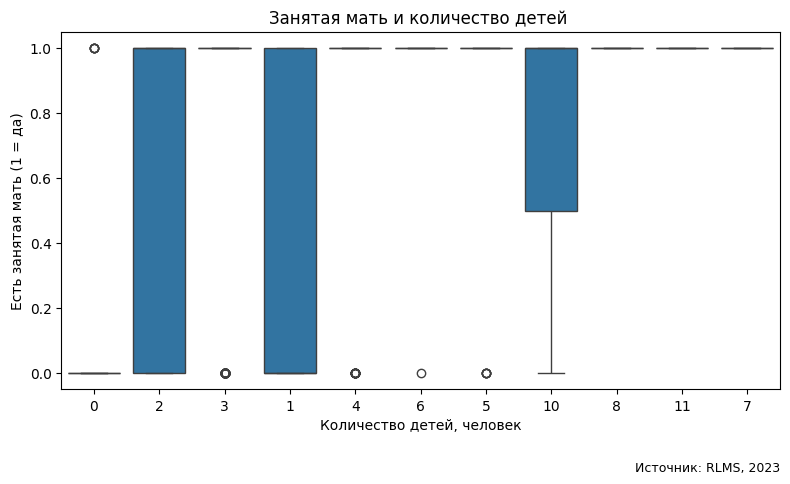


Доля домов с занятыми матерями:
children_count
0     0.002
1     0.306
2     0.636
3     0.762
4     0.776
5     0.872
6     0.933
7     1.000
8     1.000
10    0.667
11    1.000
Name: employed_mother, dtype: float64


In [ ]:
df = rlms_df.copy()

# выделяем женщин - булевый столбец
df['_is_female'] = df['bbh5'].str.contains('ЖЕН', case=False, na=False)

# выделяем детей (до 18 лет) и считаем количество в доме
df['_is_child']  = (pd.to_numeric(df['bb_age'], errors='coerce') < 18).astype(int)
kids = df.groupby('bbid_h', observed=True)['_is_child'].sum().rename('kids_u18')
df   = df.merge(kids, on='bbid_h')
# хотя бы 1 ребенок + женщина = мать
df['_is_mother'] = df['_is_female'] & (df['kids_u18'] > 0)

# работает или ищет работу - булев флаг
work_str = df['bbj90'].astype(str)
df['_is_employed'] = work_str.str.contains(r'РАБОТАЕТ|ИЩЕТ', case=False, na=False)

# мать + занята(ищет) = 1 , иначе 0
df['employed_mother_ind'] = (df['_is_mother'] & df['_is_employed']).astype(int)

# есть ли занятая мама в доме?
employed_mother_hh = (df.groupby('bbid_h', observed=True)['employed_mother_ind']
                        .max().reset_index()
                        .rename(columns={'employed_mother_ind':'employed_mother'}))

#  добавляем флаг занятой мамы к таблице домов
df_h2 = (df_h
         .merge(employed_mother_hh, on='bbid_h', how='left')
         .fillna({'employed_mother':0})
         .astype({'employed_mother':int}))

# проверяем
busy = int(df_h2['employed_mother'].sum())
print(f"Домохозяйств с занятыми матерями: {busy} / {len(df_h2)}")

# рисуем
if busy:
    df_h2['children_count_cat'] = df_h2['children_count'].astype(int).astype(str)

    plt.figure(figsize=(8,5))
    sns.boxplot(data=df_h2, x='children_count_cat', y='employed_mother')
    plt.title('Занятая мать и количество детей ')
    plt.xlabel('Количество детей, человек'); plt.ylabel('Есть занятая мать (1 = да)')
    plt.text(1.0, -0.2, 'Источник: RLMS, 2023',
         ha='right', va='top', fontsize=9, transform=plt.gca().transAxes)
    plt.tight_layout(); plt.show()

    print("\nДоля домов с занятыми матерями:")
    print(df_h2.groupby('children_count')['employed_mother'].mean().round(3))
else:
    print("\nВсё ещё 0? Посмотрите реальные строки bbj90:")
    display(df['bbj90'].value_counts(dropna=False).head(20))

Гипотеза 3: Семейное положение

Гипотеза: Женатые или замужние индивиды имеют больше детей из-за социальных норм и стабильности.

1. «В сводных семьях супруги чаще планируют иметь второго (общего) ребёнка — 72%, нежели в нормативных ячейках — 53%»

Источник: Гурко Т. А. Репродуктивные планы супругов и влияющие на них факторы // Социологические исследования. — 2014. — № 2. — С. 73–81.

2. «Наличие партнёра продолжает оставаться одним из условий, способствующих росту числа детей у женщины»
В регрессионной модели переменная "замужем" имеет положительное и значимое влияние на число детей (коэффициент ~0.46)

Источник: Карабчук Т. С., Кечетова А. П. Количество детей и семейные ценности: существуют ли когортные различия в Европе? // Журнал исследований социальной политики. — 2017. — Т. 15, № 2. — С. 245–266. — DOI: 10.17323/727-0634-2017-15-2-245-266.

Этими источниками мы подтвержаем свою гипотезу.
Переменная: bb_marst (семейное положение)



Домов, где есть ≥1 взрослый в браке: 2714 / 4788


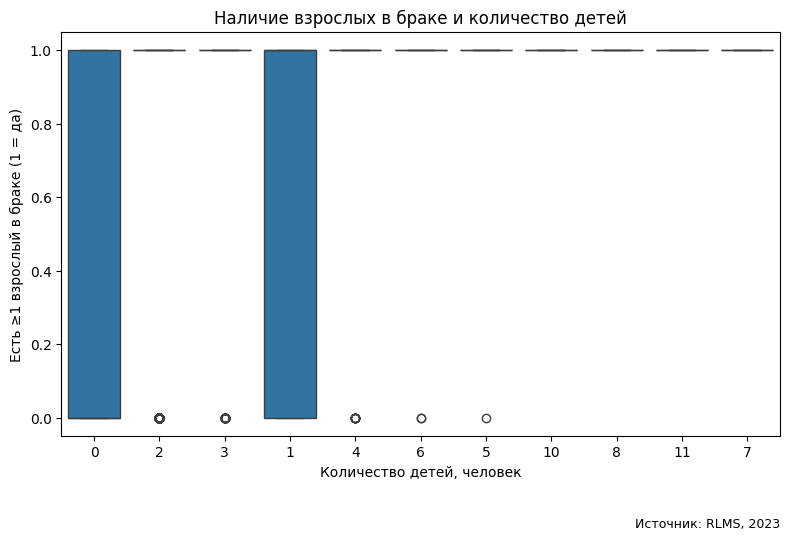


Доли домов с ≥1 взрослым в браке:
children_count
0     0.413
1     0.639
2     0.804
3     0.844
4     0.908
5     0.974
6     0.867
7     1.000
8     1.000
10    1.000
11    1.000
Name: any_married_adult, dtype: float64


In [ ]:
df = rlms_df.copy()

# преобразуем возраст в цифры и ищем взрослых
df['_age']   = pd.to_numeric(df['bb_age'], errors='coerce')
df['_adult'] = df['_age'] >= 18

# ищем браки
mar_col = 'bb_marst'
mar_str = df[mar_col].astype(str)
pat = re.compile(
    r'^состоите в зарегистрированном браке'
    r'|^живете вместе, но не зарегистрированы'
    r'|^официально зарегистрированы, но вместе не проживают',
    flags=re.I # регистронезависимый поиск
)

# взрослые в браке
df['_is_married'] = mar_str.fillna('').str.match(pat) & df['_adult']


# есть ли в доме хотя бы 1 взрослый в браке
married_any_hh = (df.groupby('bbid_h', observed=True)['_is_married']
                    .max().reset_index(name='any_married_adult'))

# обьединяем с таблицей домохозяйств
df_h3 = (df_h
         .merge(married_any_hh, on='bbid_h', how='left')
         .fillna({'any_married_adult': 0}) # если данных нет, считаем как "никто не женат"
         .astype({'any_married_adult': int}))

print("Домов, где есть ≥1 взрослый в браке:",
      df_h3['any_married_adult'].sum(), "/", len(df_h3))

# для ящика с усами преобразуем как категорию
df_h3['children_count_cat'] = df_h3['children_count'].astype(int).astype(str)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_h3,
            x='children_count_cat',
            y='any_married_adult')
plt.title('Наличие взрослых в браке и количество детей')
plt.xlabel('Количество детей, человек')
plt.ylabel('Есть ≥1 взрослый в браке (1 = да)')
plt.tight_layout()
plt.text(1.0, -0.2, 'Источник: RLMS, 2023',
         ha='right', va='top', fontsize=9, transform=plt.gca().transAxes)
plt.show()

print("\nДоли домов с ≥1 взрослым в браке:")
print(df_h3.groupby('children_count')['any_married_adult'].mean().round(3))

Проведя исследование, выяснили, что на количество детей в семье влияет целый ряд социально-экономических факторов. Прежде всего, влияет место проживания: семьи, живущие в сельской местности, в среднем имеют больше детей по сравнению с жителями городов. Это подтверждается и при подсчёте численности населённых пунктов — в менее населённых территориях рождаемость выше.

Также важным фактором выступает семейное положение: люди, состоящие в браке, чаще имеют больше детей, чем холостые. Государству важно получать эти данные, потому что, например, они могут устанавливать специальные ставки по ипотеке для семей в зависимости от количества детей. Доход семьи также играет роль — более обеспеченные семьи чаще решаются на рождение детей. Однако сельские семьи все ещё лидируют по числу детей.

Внимательно рассмотрели уровень образования и занятости. Выяснилось, что чем выше уровень образования родителей, тем меньше у них детей. Это подтверждает гипотезу о том, что более образованные люди склонны откладывать рождение детей, уделяя приоритетное внимание карьерному росту. Аналогично, занятость родителей, особенно матерей, влечет пониженную рождаемость. Из-за того что матери работают на полную ставку им не хватает времени на семью, поэтому правительство может отслеживать эти данные и принимать меры, например, укорачивать рабочие дни, сохраненяя прежнюю ставку.

В совокупности эти результаты показывают влияние всех факторов на размер семьи в России и являются важными данными для формирования дальнейшей демографической и социальной политики страны. Также они могут использоваться для разработки проектов по поддержке групп риска.

Также источники, которыми мы пользовались, кроме упомянутых выше
1. Miettinen A., Basten S., Rotkirch A. (2011) Gender equality and fertility intentions revisited: Evidence from Finland. Demographic research. Vol. 24. P. 469—49
2. Кузьмин А. И., Примак Т. В., Кузьмина А. А. Воспроизводство населения в регионах России //Экономика региона. – 2011. – №. 1. – С. 32-41.
3. Meyer D., Cancian M., Cook S. (2005) Multiple-partner fertility: Incidence and implications for child support policy. Social Service Review. Vol. 79. P. 577—601. DOI:10.1086/454386.
4. Ильдарханова Ч. И., Ершова Г. Н. Образовательные траектории родителей как фактор репродуктивного поведения на примере Республики Татарстан (2013–2022 гг.) //Высшее образование в России. – 2024. – Т. 33. – №. 7. – С. 50-66.
5. Kravdal Ø., Rindfuss R.R. (2008) Changing relationships between education and
fertility: A study of women and men born 1940 to 1964. American Sociological Review. Vol. 73. No. 5. P. 854—873

